# 🌳 Decision Tree on the MNIST Dataset (Handwritten Digits)

This notebook applies a **Decision Tree** to recognize digits from 0 to 9.
A quick reminder of this algorithm's strengths:
1. **ZERO Normalization:** No need to scale the pixels (0 to 255), the tree adapts on its own.
2. **Active Training:** Once the tree is built, it forgets the dataset and keeps only its logical rules.

We will look at the effect of the `max_depth` parameter on controlling overfitting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- LOADING YOUR LOCAL DATASET INSIDE DOCKER ---
# Adjust these lines to match the exact format of your file inside your container
try:
    # Example 1: If your MNIST is a local CSV file
    # data_mnist = pd.read_csv("path/to/your/mnist.csv")
    # X = data_mnist.drop(columns=['label']).values
    # y = data_mnist['label'].values
    
    # Example 2: If you downloaded it through Sklearn OpenML with a local cache
    from sklearn.datasets import fetch_openml
    print("Trying to load from your local Sklearn cache...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto', data_home="./mnist_cache")
    X, y = mnist.data, mnist.target.astype(int)
    
    print("MNIST dataset loaded successfully from local storage!")
except Exception as e:
    print(f"Loading error. Adjust this cell with your Docker file path. Details: {e}")

# Split: 80% training, 20% test (No StandardScaler needed for the tree!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Trying to load from your local Sklearn cache...
MNIST dataset loaded successfully from local storage!


## Step 2: Control the Depth to Avoid Overfitting

If we don't limit the tree, it will keep asking questions until it isolates every pixel of noise.
We will test depths from 2 to 20 levels to find the ideal cutoff (`max_depth`).

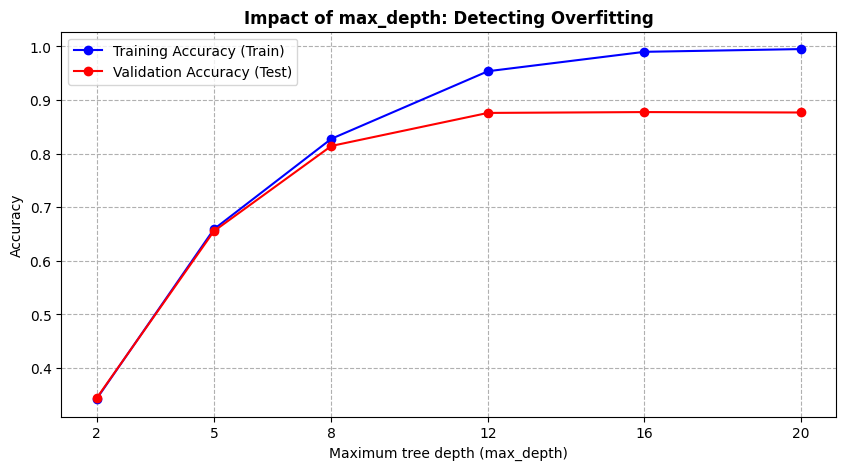

In [2]:
# Depths to test
depths = [2, 5, 8, 12, 16, 20]
train_scores = []
test_scores = []

for d in depths:
    # Initialize the tree with the current depth limit
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    
    # Build the decision rules (full training)
    tree.fit(X_train, y_train)
    
    # Evaluate on Train and Test
    train_scores.append(accuracy_score(y_train, tree.predict(X_train)))
    test_scores.append(accuracy_score(y_test, tree.predict(X_test)))

# ---- PERFORMANCE PLOT ----
plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label="Training Accuracy (Train)", color="blue", marker="o")
plt.plot(depths, test_scores, label="Validation Accuracy (Test)", color="red", marker="o")

plt.title("Impact of max_depth: Detecting Overfitting", fontsize=12, fontweight='bold')
plt.xlabel("Maximum tree depth (max_depth)")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

## Step 3: Train the Final Model

Looking at the graph, you'll notice that beyond a certain depth, the blue curve (Train) keeps climbing toward 100% while the red curve (Test) stalls or drops. This is the **Overfitting** zone.
Let's pick the depth that gives the best score on the red curve.

In [3]:
# Optimal depth chosen from the visual analysis (often around 12 for MNIST)
optimal_depth = 12

# Build the final, depth-limited decision tree
final_model = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)

# Final training (rule generation)
final_model.fit(X_train, y_train)

# Predict on the test images (instant reasoning through the tree of questions)
predictions = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, predictions)
print(f"🎯 Overall tree accuracy on MNIST (max_depth={optimal_depth}): {final_accuracy:.2%}")

🎯 Overall tree accuracy on MNIST (max_depth=12): 87.60%


## Step 4: Local Error Analysis (Confusion Matrix)

Since we have 10 classes (digits 0 to 9), the matrix will be a $10 \times 10$ table.
It lets us see right away whether our tree's questions tend to confuse digits that look alike, like **3** and **8**, or **4** and **9**.

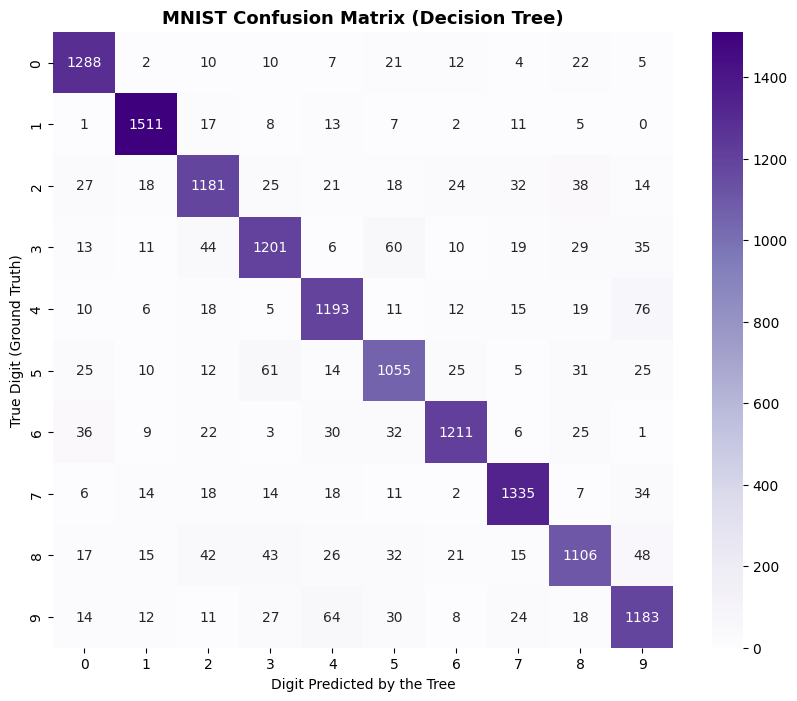


=== CLASSIFICATION REPORT FOR EACH DIGIT ===
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1381
           1       0.94      0.96      0.95      1575
           2       0.86      0.84      0.85      1398
           3       0.86      0.84      0.85      1428
           4       0.86      0.87      0.87      1365
           5       0.83      0.84      0.83      1263
           6       0.91      0.88      0.90      1375
           7       0.91      0.92      0.91      1459
           8       0.85      0.81      0.83      1365
           9       0.83      0.85      0.84      1391

    accuracy                           0.88     14000
   macro avg       0.87      0.87      0.87     14000
weighted avg       0.88      0.88      0.88     14000



In [4]:
# Compute the overall confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)

# Plot it as a Seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])

plt.title(f"MNIST Confusion Matrix (Decision Tree)", fontsize=13, fontweight='bold')
plt.ylabel("True Digit (Ground Truth)")
plt.xlabel("Digit Predicted by the Tree")
plt.show()

# Detailed metrics per digit
print("\n=== CLASSIFICATION REPORT FOR EACH DIGIT ===")
print(classification_report(y_test, predictions))

## Step 5: Visualizing the Decision Tree Structure

To see exactly how our "methodical detective" asks its questions, we can draw its geometric structure.

Each box (node) shows you:
*   The question asked (e.g., `Pixel_350 <= 12.5`).
*   The **Gini** index (the current level of impurity).
*   The box color, which represents the majority class at that stage (the darker the color, the purer the node).

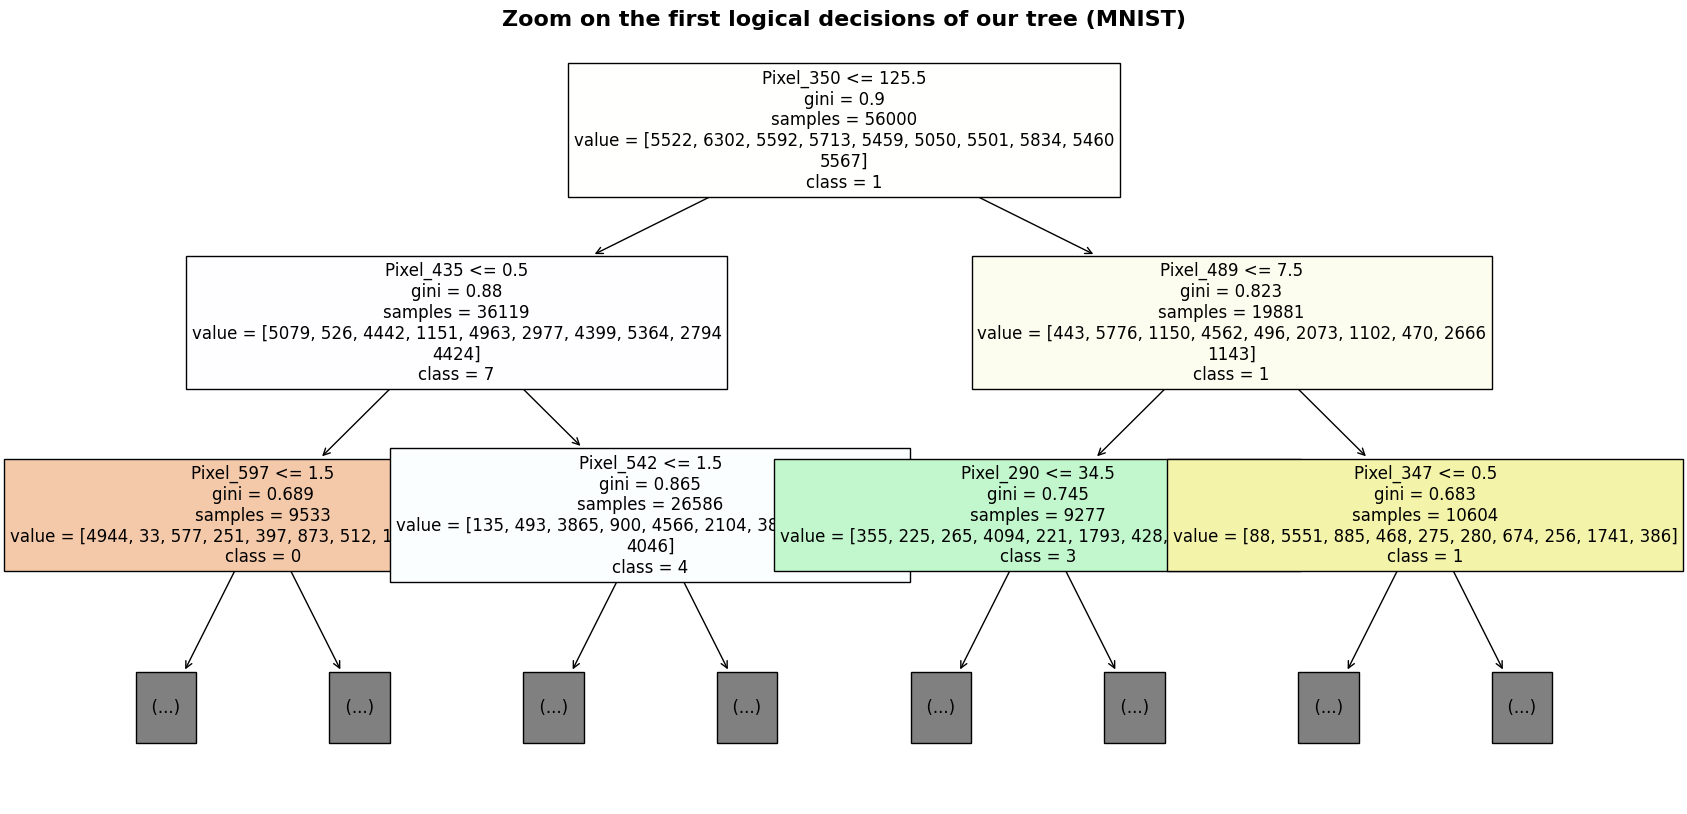

In [5]:
# Import Scikit-Learn's tree-drawing tool
from sklearn.tree import plot_tree

# 1. Set a large figure size to keep the text readable
plt.figure(figsize=(20, 10))

# 2. Draw the tree
# max_depth=2 zooms in on just the root and the first 2 levels of branches
# filled=True colors the boxes by the detected majority digit
plot_tree(final_model, 
          max_depth=2, 
          filled=True, 
          feature_names=[f"Pixel_{i}" for i in range(X.shape[1])],
          class_names=[str(i) for i in range(10)],
          fontsize=12)

# 3. Set the title and show the final figure
plt.title("Zoom on the first logical decisions of our tree (MNIST)", fontsize=16, fontweight='bold')
plt.show()